In [1]:
# Importing Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    make_scorer
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier

# Load the sample dataset
original_bank = pd.read_csv("/Users/Owner/Desktop/Bank-Project/Datasets/bank/bank.csv", sep=";")

X = original_bank.drop(columns=["y"])
y = original_bank["y"].map({"no": 0, "yes": 1})

categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("Dataset shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

Dataset shape: (4521, 16)

Class distribution:
y
0    4000
1     521
Name: count, dtype: int64


In [2]:
# Helper preprocessing setup
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Scoring setup
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

In [3]:
# Building the XGB baseline model with 10-fold CV
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    ))
])

baseline_cv_results = cross_validate(
    baseline_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

baseline_summary = pd.DataFrame([{
    "Scenario": "XGBoost + SMOTE (Baseline, 10-fold CV)",
    "Accuracy": baseline_cv_results["test_accuracy"].mean(),
    "Precision": baseline_cv_results["test_precision"].mean(),
    "Recall": baseline_cv_results["test_recall"].mean(),
    "F1-score": baseline_cv_results["test_f1"].mean(),
    "ROC-AUC": baseline_cv_results["test_roc_auc"].mean()
}])

print(baseline_summary.round(4))

                                 Scenario  Accuracy  Precision  Recall  \
0  XGBoost + SMOTE (Baseline, 10-fold CV)    0.8923     0.5416  0.4319   

   F1-score  ROC-AUC  
0    0.4801   0.9051  


In [4]:
# CV configuration and paper-informed search space
param_dist = {
    "xgb__n_estimators": [70, 100, 150, 200, 300],
    "xgb__max_depth": [4, 5, 6, 7, 8, 9],
    "xgb__learning_rate": [0.03, 0.05, 0.1],
    "xgb__subsample": [0.80, 0.85, 0.90, 1.0],
    "xgb__colsample_bytree": [0.70, 0.80, 0.90, 1.0],
    "xgb__min_child_weight": [1, 3, 5, 7],
    "xgb__gamma": [0, 0.5, 1, 2],
    "xgb__reg_alpha": [0, 0.01, 0.1, 0.5],
    "xgb__reg_lambda": [0.1, 0.5, 1.0, 2.0, 5.0]
}

tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    ))
])

xgb_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    refit=True
)

xgb_search.fit(X, y)


Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0.5, xgb__learning_rate=0.03, xgb__max_depth=5, xgb__min_child_weight=7, xgb__n_estimators=70, xgb__reg_alpha=0.5, xgb__reg_lambda=0.5, xgb__subsample=1.0; total time=   0.1s
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0.5, xgb__learning_rate=0.03, xgb__max_depth=5, xgb__min_child_weight=7, xgb__n_estimators=70, xgb__reg_alpha=0.5, xgb__reg_lambda=0.5, xgb__subsample=1.0; total time=   0.2s
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0.5, xgb__learning_rate=0.03, xgb__max_depth=5, xgb__min_child_weight=7, xgb__n_estimators=70, xgb__reg_alpha=0.5, xgb__reg_lambda=0.5, xgb__subsample=1.0; total time=   0.2s
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0.5, xgb__learning_rate=0.03, xgb__max_depth=5, xgb__min_child_weight=7, xgb__n_estimators=70, xgb__reg_alpha=0.5, xgb__reg_lambda=0.5, xgb__subsample=1.0; total time=   0.1s
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0.

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgb__colsample_bytree': [0.7, 0.8, ...], 'xgb__gamma': [0, 0.5, ...], 'xgb__learning_rate': [0.03, 0.05, ...], 'xgb__max_depth': [4, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can

In [5]:
cv_results_df = pd.DataFrame(xgb_search.cv_results_).sort_values(
    by="rank_test_score"
).reset_index(drop=True)

print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest mean CV F1:")
print(round(xgb_search.best_score_, 4))

print("\nCross-validation configuration:")
print(cv)

Best parameters:
{'xgb__subsample': 0.8, 'xgb__reg_lambda': 5.0, 'xgb__reg_alpha': 0.01, 'xgb__n_estimators': 150, 'xgb__min_child_weight': 3, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.03, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.9}

Best mean CV F1:
0.5541

Cross-validation configuration:
StratifiedKFold(n_splits=10, random_state=42, shuffle=True)


In [6]:
# Tuned model evaluated with 10-fold CV
xgb_tuned = xgb_search.best_estimator_

tuned_cv_results = cross_validate(
    xgb_tuned,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

tuned_summary = pd.DataFrame([{
    "Scenario": "XGBoost + SMOTE (Tuned RandomizedSearchCV, 10-fold CV)",
    "Accuracy": tuned_cv_results["test_accuracy"].mean(),
    "Precision": tuned_cv_results["test_precision"].mean(),
    "Recall": tuned_cv_results["test_recall"].mean(),
    "F1-score": tuned_cv_results["test_f1"].mean(),
    "ROC-AUC": tuned_cv_results["test_roc_auc"].mean()
}])

print(tuned_summary.round(4))

                                            Scenario  Accuracy  Precision  \
0  XGBoost + SMOTE (Tuned RandomizedSearchCV, 10-...    0.8879     0.5094   

   Recall  F1-score  ROC-AUC  
0  0.6103    0.5541   0.9028  


In [7]:
# Baseline vs Tuned comparison
results_df = pd.concat([baseline_summary, tuned_summary], ignore_index=True)
print(results_df.round(4))

                                            Scenario  Accuracy  Precision  \
0             XGBoost + SMOTE (Baseline, 10-fold CV)    0.8923     0.5416   
1  XGBoost + SMOTE (Tuned RandomizedSearchCV, 10-...    0.8879     0.5094   

   Recall  F1-score  ROC-AUC  
0  0.4319    0.4801   0.9051  
1  0.6103    0.5541   0.9028  


In [8]:
# Top SearchCV results
top_cv = cv_results_df[[
    "params",
    "mean_test_score",
    "std_test_score"
]].head(10).copy()

print(top_cv)

                                              params  mean_test_score  \
0  {'xgb__subsample': 0.8, 'xgb__reg_lambda': 5.0...         0.554122   
1  {'xgb__subsample': 0.9, 'xgb__reg_lambda': 5.0...         0.554052   
2  {'xgb__subsample': 1.0, 'xgb__reg_lambda': 2.0...         0.550578   
3  {'xgb__subsample': 1.0, 'xgb__reg_lambda': 5.0...         0.547677   
4  {'xgb__subsample': 0.9, 'xgb__reg_lambda': 1.0...         0.544930   
5  {'xgb__subsample': 0.9, 'xgb__reg_lambda': 0.1...         0.544626   
6  {'xgb__subsample': 0.8, 'xgb__reg_lambda': 5.0...         0.544026   
7  {'xgb__subsample': 0.85, 'xgb__reg_lambda': 2....         0.543529   
8  {'xgb__subsample': 0.85, 'xgb__reg_lambda': 1....         0.542237   
9  {'xgb__subsample': 0.85, 'xgb__reg_lambda': 1....         0.538677   

   std_test_score  
0        0.069409  
1        0.059664  
2        0.064084  
3        0.071901  
4        0.058683  
5        0.062514  
6        0.067519  
7        0.054736  
8        0.05802

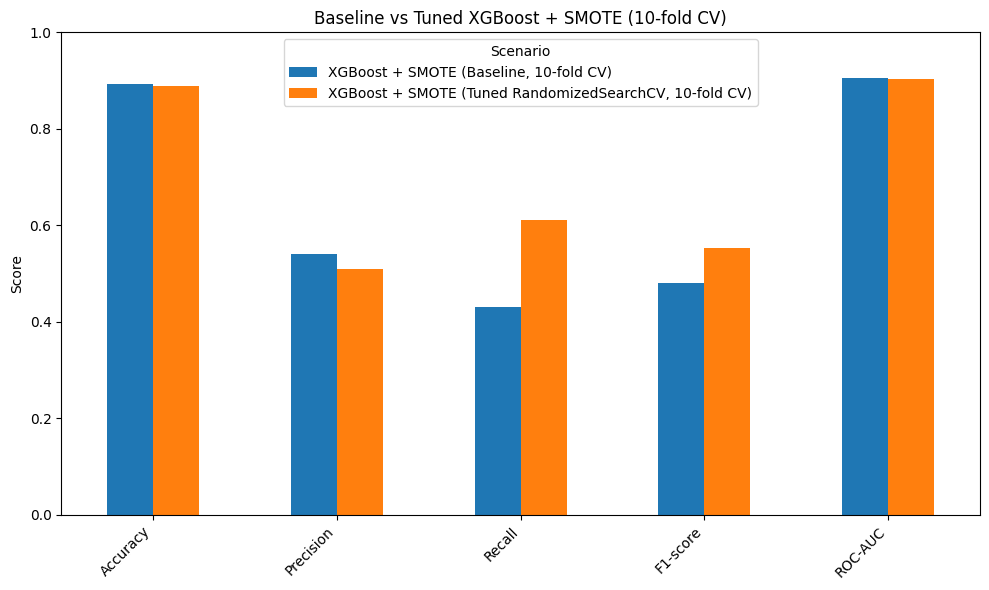

In [9]:
# Grouped bar plotting
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

plot_df = results_df.set_index("Scenario")[metrics].T

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Baseline vs Tuned XGBoost + SMOTE (10-fold CV)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

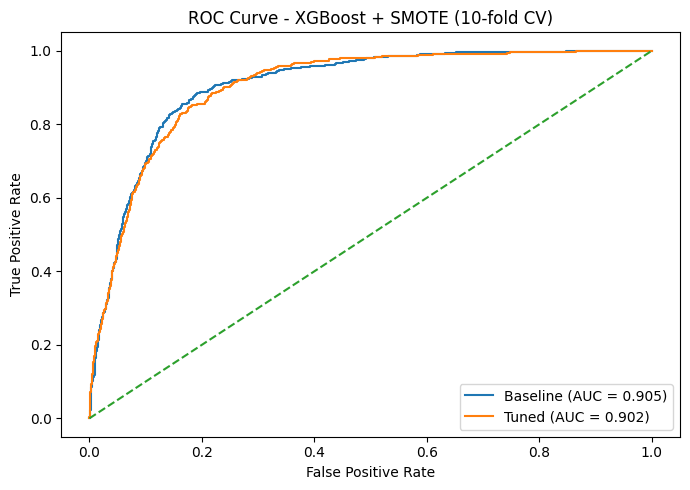

In [10]:
# ROC Curve Plotting using out-of-fold predictions
baseline_oof_proba = cross_val_predict(
    baseline_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

tuned_oof_proba = cross_val_predict(
    xgb_tuned,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

fpr_base, tpr_base, _ = roc_curve(y, baseline_oof_proba)
auc_base = auc(fpr_base, tpr_base)

fpr_tuned, tpr_tuned, _ = roc_curve(y, tuned_oof_proba)
auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(7, 5))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC = {auc_base:.3f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"Tuned (AUC = {auc_tuned:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost + SMOTE (10-fold CV)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Top CV parameter combinations
top_cv = cv_results_df[[
    "params",
    "mean_test_score",
    "std_test_score"
]].head(10).copy()

print(top_cv)

                                              params  mean_test_score  \
0  {'xgb__subsample': 0.8, 'xgb__reg_lambda': 5.0...         0.554122   
1  {'xgb__subsample': 0.9, 'xgb__reg_lambda': 5.0...         0.554052   
2  {'xgb__subsample': 1.0, 'xgb__reg_lambda': 2.0...         0.550578   
3  {'xgb__subsample': 1.0, 'xgb__reg_lambda': 5.0...         0.547677   
4  {'xgb__subsample': 0.9, 'xgb__reg_lambda': 1.0...         0.544930   
5  {'xgb__subsample': 0.9, 'xgb__reg_lambda': 0.1...         0.544626   
6  {'xgb__subsample': 0.8, 'xgb__reg_lambda': 5.0...         0.544026   
7  {'xgb__subsample': 0.85, 'xgb__reg_lambda': 2....         0.543529   
8  {'xgb__subsample': 0.85, 'xgb__reg_lambda': 1....         0.542237   
9  {'xgb__subsample': 0.85, 'xgb__reg_lambda': 1....         0.538677   

   std_test_score  
0        0.069409  
1        0.059664  
2        0.064084  
3        0.071901  
4        0.058683  
5        0.062514  
6        0.067519  
7        0.054736  
8        0.05802

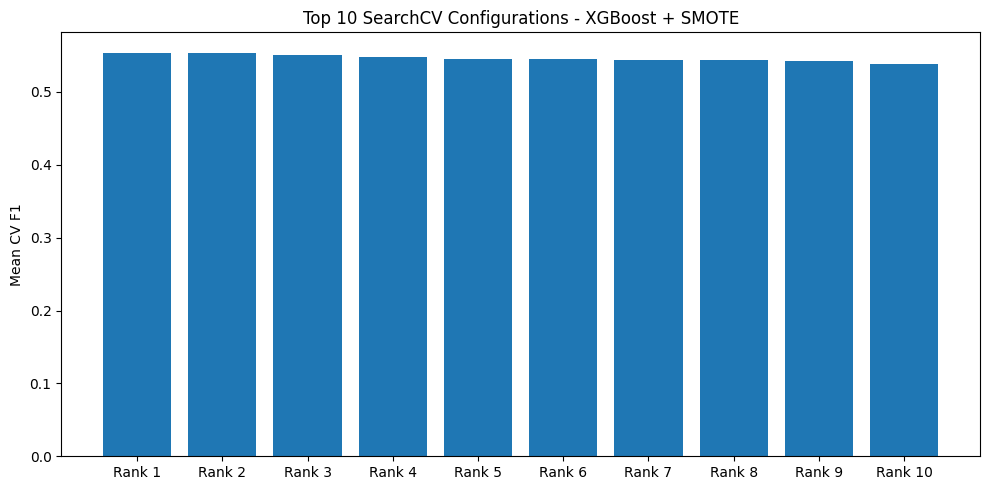

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(top_cv)), top_cv["mean_test_score"])
plt.xticks(range(len(top_cv)), [f"Rank {i+1}" for i in range(len(top_cv))])
plt.ylabel("Mean CV F1")
plt.title("Top 10 SearchCV Configurations - XGBoost + SMOTE")
plt.tight_layout()
plt.show()

In [13]:
# Fold-by-fold results
baseline_folds_df = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": baseline_cv_results["test_accuracy"],
    "Precision": baseline_cv_results["test_precision"],
    "Recall": baseline_cv_results["test_recall"],
    "F1-score": baseline_cv_results["test_f1"],
    "ROC-AUC": baseline_cv_results["test_roc_auc"]
})

tuned_folds_df = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": tuned_cv_results["test_accuracy"],
    "Precision": tuned_cv_results["test_precision"],
    "Recall": tuned_cv_results["test_recall"],
    "F1-score": tuned_cv_results["test_f1"],
    "ROC-AUC": tuned_cv_results["test_roc_auc"]
})

print("Baseline fold results:")
print(baseline_folds_df.round(4))

print("\nTuned fold results:")
print(tuned_folds_df.round(4))

Baseline fold results:
   Fold  Accuracy  Precision  Recall  F1-score  ROC-AUC
0     1    0.8874     0.5238  0.4151    0.4632   0.9160
1     2    0.8850     0.5000  0.3654    0.4222   0.8778
2     3    0.8938     0.5455  0.4615    0.5000   0.8959
3     4    0.9093     0.6410  0.4808    0.5495   0.9329
4     5    0.8960     0.5610  0.4423    0.4946   0.8981
5     6    0.9181     0.6667  0.5769    0.6186   0.9172
6     7    0.8872     0.5128  0.3846    0.4396   0.9280
7     8    0.8628     0.3810  0.3077    0.3404   0.8758
8     9    0.8717     0.4348  0.3846    0.4082   0.8738
9    10    0.9115     0.6500  0.5000    0.5652   0.9360

Tuned fold results:
   Fold  Accuracy  Precision  Recall  F1-score  ROC-AUC
0     1    0.8985     0.5556  0.6604    0.6034   0.8857
1     2    0.8650     0.4237  0.4808    0.4505   0.8756
2     3    0.8805     0.4848  0.6154    0.5424   0.8847
3     4    0.8872     0.5098  0.5000    0.5049   0.9171
4     5    0.9049     0.5714  0.6923    0.6261   0.9246
5   

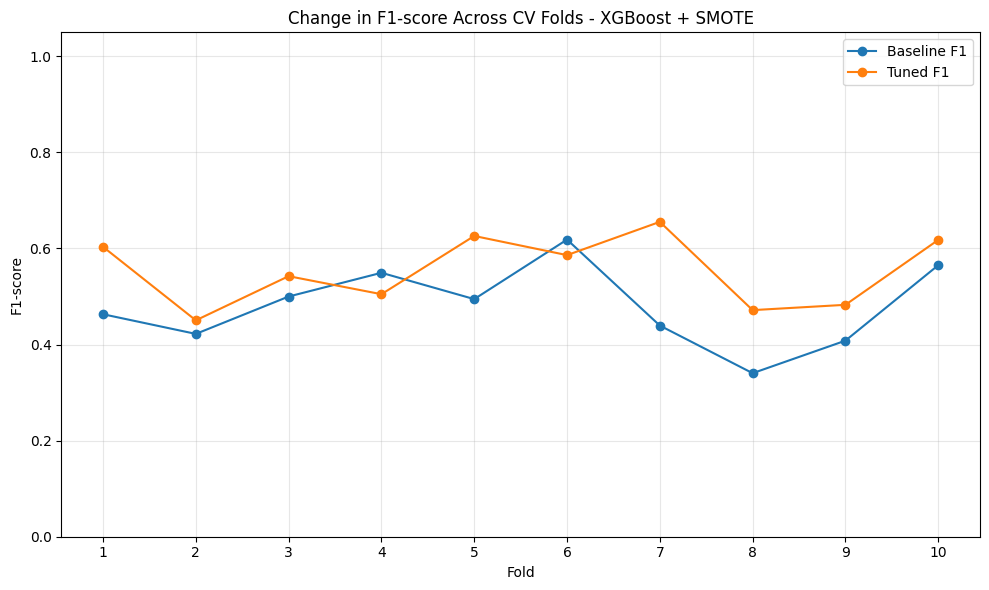

In [14]:
# Plot showing the change across CV folds
plt.figure(figsize=(10, 6))
plt.plot(baseline_folds_df["Fold"], baseline_folds_df["F1-score"], marker="o", label="Baseline F1")
plt.plot(tuned_folds_df["Fold"], tuned_folds_df["F1-score"], marker="o", label="Tuned F1")

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Change in F1-score Across CV Folds - XGBoost + SMOTE")
plt.xticks(range(1, 11))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

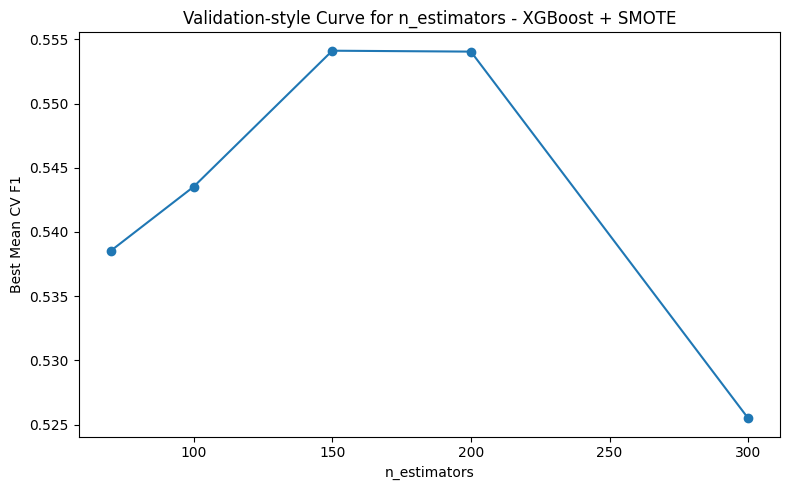

In [15]:
plot_df = cv_results_df.copy()
plot_df["n_estimators"] = plot_df["params"].apply(lambda x: x["xgb__n_estimators"])

best_by_estimators = plot_df.groupby("n_estimators")["mean_test_score"].max().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(best_by_estimators["n_estimators"], best_by_estimators["mean_test_score"], marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Best Mean CV F1")
plt.title("Validation-style Curve for n_estimators - XGBoost + SMOTE")
plt.tight_layout()
plt.show()

In [17]:
xgb_baseline_folds = baseline_folds_df.copy()
xgb_baseline_folds["Algorithm"] = "XGBoost"
xgb_baseline_folds["Version"] = "Baseline"

xgb_tuned_folds = tuned_folds_df.copy()
xgb_tuned_folds["Algorithm"] = "XGBoost"
xgb_tuned_folds["Version"] = "Tuned"

xgb_cv_folds = pd.concat([xgb_baseline_folds, xgb_tuned_folds], ignore_index=True)

xgb_cv_folds.to_csv("xgb_cv_folds.csv", index=False)
xgb_cv_folds

,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC,Algorithm,Version
0,1,0.887417,0.523810,0.415094,0.463158,0.915991,XGBoost,Baseline
1,2,0.884956,0.500000,0.365385,0.422222,0.877837,XGBoost,Baseline
2,3,0.893805,0.545455,0.461538,0.500000,0.895865,XGBoost,Baseline
3,4,0.909292,0.641026,0.480769,0.549451,0.932933,XGBoost,Baseline
4,5,0.896018,0.560976,0.442308,0.494624,0.898125,XGBoost,Baseline
5,6,0.918142,0.666667,0.576923,0.618557,0.917163,XGBoost,Baseline
6,7,0.887168,0.512821,0.384615,0.439560,0.928029,XGBoost,Baseline
7,8,0.862832,0.380952,0.307692,0.340426,0.875769,XGBoost,Baseline
8,9,0.871681,0.434783,0.384615,0.408163,0.873798,XGBoost,Baseline
9,10,0.911504,0.650000,0.500000,0.565217,0.935962,XGBoost,Baseline
